               close      high       low      open     volume  log_return  \
Date                                                                        
2010-03-17  8.004286  8.087500  7.973929  8.032143  450956800   -0.001471   
2010-03-18  8.023214  8.035714  7.950357  8.003571  342109600    0.002362   
2010-03-19  7.937500  8.044286  7.901071  8.028214  559445600   -0.010741   
2010-03-22  8.026786  8.071429  7.862500  7.873929  456419600    0.011186   
2010-03-23  8.155714  8.170714  8.003571  8.058571  602431200    0.015935   

              return    sma_10    sma_20    sma_50  ...  price_sma_20  \
Date                                                ...                 
2010-03-17 -0.001470  7.932536  7.602929  7.398557  ...      1.052790   
2010-03-18  0.002365  7.982321  7.641714  7.405893  ...      1.049923   
2010-03-19 -0.010683  7.994107  7.678464  7.413950  ...      1.033735   
2010-03-22  0.011249  8.014357  7.721911  7.424071  ...      1.039482   
2010-03-23  0.016062  

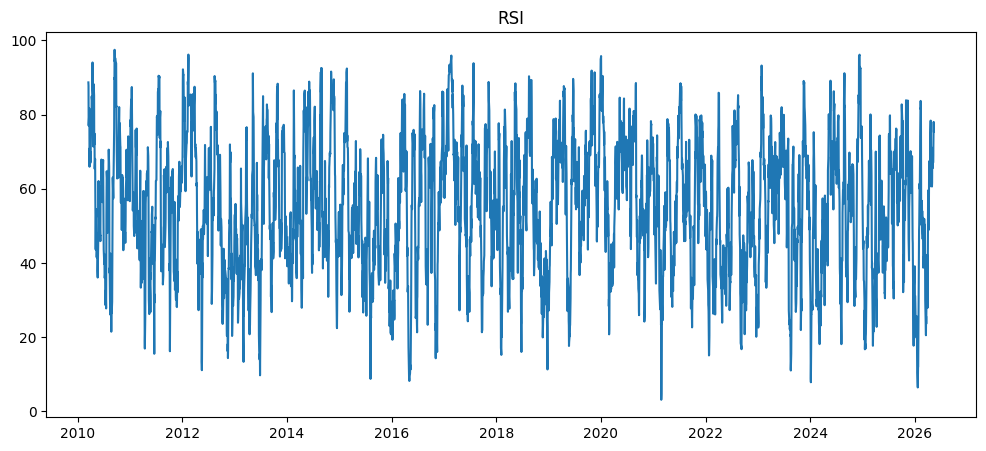

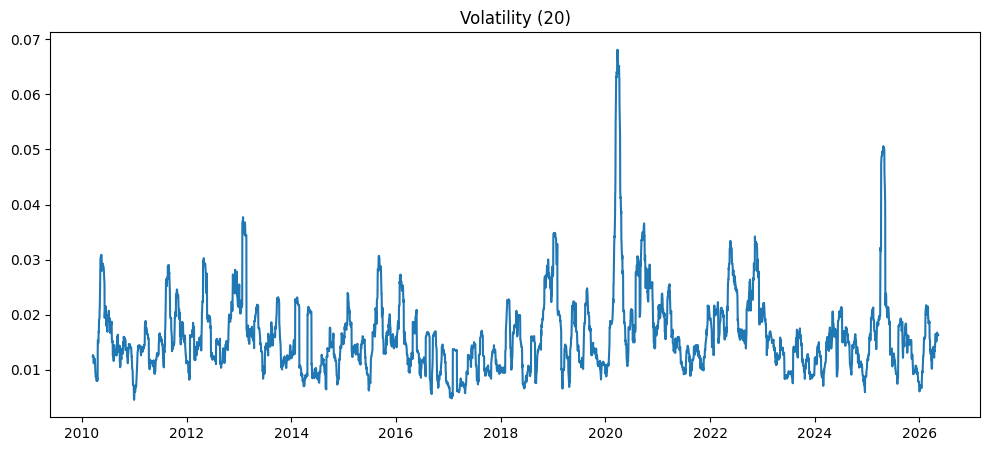

FEATURE ENGINEERING DONE


In [1]:

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ticker = "AAPL"

raw = yf.download(
    ticker,
    start="2010-01-01",
    progress=False,
    auto_adjust=False,
    threads=False
)

df = pd.DataFrame(index=raw.index)

for col in raw.columns:
    name = str(col).lower()

    if "close" in name:
        df["close"] = raw[col]
    if "open" in name:
        df["open"] = raw[col]
    if "high" in name:
        df["high"] = raw[col]
    if "low" in name:
        df["low"] = raw[col]
    if "volume" in name:
        df["volume"] = raw[col]

df = df.dropna()

df["log_return"] = np.log(df["close"] / df["close"].shift(1))
df["return"] = df["close"].pct_change()
df = df.dropna()

df["sma_10"] = df["close"].rolling(10).mean()
df["sma_20"] = df["close"].rolling(20).mean()
df["sma_50"] = df["close"].rolling(50).mean()

df["price_sma_10"] = df["close"] / df["sma_10"]
df["price_sma_20"] = df["close"] / df["sma_20"]

df["vol_10"] = df["log_return"].rolling(10).std()
df["vol_20"] = df["log_return"].rolling(20).std()

delta = df["close"].diff()
gain = (delta.where(delta > 0, 0)).rolling(14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(14).mean()

rs = gain / (loss + 1e-9)
df["rsi"] = 100 - (100 / (1 + rs))

df["mom_5"] = df["close"] - df["close"].shift(5)
df["mom_10"] = df["close"] - df["close"].shift(10)

for lag in [1, 2, 3, 5]:
    df[f"lag_{lag}"] = df["log_return"].shift(lag)

df = df.dropna()

print(df.head())
print(df.columns)

plt.figure(figsize=(12,5))
plt.plot(df["rsi"])
plt.title("RSI")
plt.show()

plt.figure(figsize=(12,5))
plt.plot(df["vol_20"])
plt.title("Volatility (20)")
plt.show()

print("FEATURE ENGINEERING DONE")